# Построение модели

## Импорты

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
from collections import Counter
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_id = '1RJE0KfEf7sK_mRpcmIYg_j2RrSowKHkX'
url = f'https://drive.google.com/uc?id={file_id}'
output = '2026-04-20_17-10-56_e6g6o9r_merged_dataframe.csv'

if not os.path.exists(output):
    print("Скачиваем...")
    gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
print(f"Строк: {len(df)}, колонок: {len(df.columns)}")
print(f"course_ended есть: {'course_ended' in df.columns}")
print(f"target есть: {'target' in df.columns}")

if 'course_ended' in df.columns:
    print(f"course_ended: {df['course_ended'].value_counts()}")
if 'target' in df.columns:
    print(f"target:{df['target'].value_counts()}")

Строк: 267206, колонок: 65
course_ended есть: True
target есть: True
course_ended: course_ended
0    205355
1     61851
Name: count, dtype: int64
target:target
0    263300
1      3906
Name: count, dtype: int64


## Работа с данными

In [3]:
df = df[df['course_ended'] == 1]

df['target'].unique()

array([0, 1])

Ошибок нет.

In [4]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

target
0    61646
1      205
Name: count, dtype: int64
target
0    0.997
1    0.003
Name: proportion, dtype: float64


Соотношение: 0.33% успешных пар против 99.67% неуспешных.

In [5]:
# Количество уникальных пар user_id + course_id
unique_pairs = df[['user_id', 'course_id']].drop_duplicates().shape[0]

# Количество строк в df
total_rows = len(df)

print(f"Уникальных пар (user_id, course_id): {unique_pairs}")
print(f"Строк в df: {total_rows}")
print(f"Совпадают: {unique_pairs == total_rows}")

Уникальных пар (user_id, course_id): 61851
Строк в df: 61851
Совпадают: True


Убеждаемся - ошибок нет.

In [6]:
user_stats = df.groupby('user_id')['target'].agg(['nunique', 'count'])
mixed = user_stats[user_stats['nunique'] > 1]

print(f"Всего студентов: {len(user_stats)}")
print(f"С разными target: {len(mixed)} ({len(mixed)/len(user_stats)*100:.1f}%)")
print(f"С одним target: {len(user_stats) - len(mixed)}")

Всего студентов: 29612
С разными target: 1 (0.0%)
С одним target: 29611


Подавляющее большинство студентов ведут себя одинаково на всех курсах - либо всегда успешны, либо всегда неуспешны.

Только 1 студент (!) имеет разный target на разных курсах (например, на одном курсе завершил, на другом - нет).

Неуспешные студенты записываются на много курсов и на всех неуспешны, что раздувает количество пар с target=0.

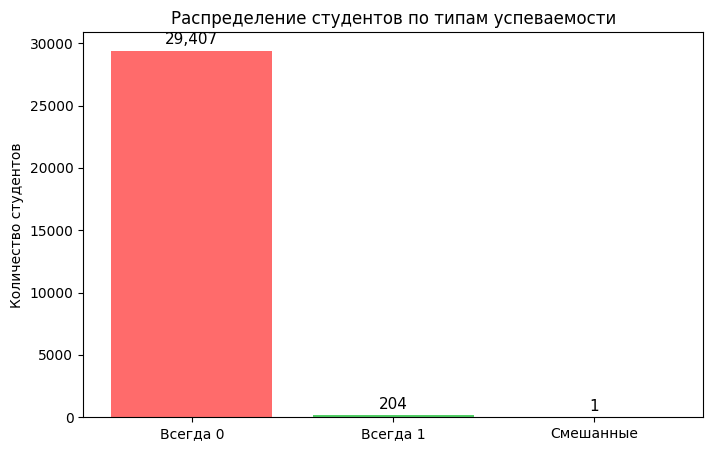

In [7]:
# Считаем типы студентов
user_stats = df.groupby('user_id')['target'].agg(['mean', 'nunique'])
user_stats['type'] = 0
user_stats.loc[user_stats['mean'] == 1, 'type'] = 1
user_stats.loc[(user_stats['mean'] > 0) & (user_stats['mean'] < 1), 'type'] = 2

# Данные для графика
counts = user_stats['type'].value_counts().sort_index()
labels = ['Всегда 0', 'Всегда 1', 'Смешанные']
colors = ['#ff6b6b', '#51cf66', '#ffd43b']

# Бар чарт
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=colors)
plt.title('Распределение студентов по типам успеваемости')
plt.ylabel('Количество студентов')

# Подписи на столбцах
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{count:,}', ha='center', fontsize=11)

plt.show()

In [8]:
# Создаем датафрейм, где одна строка = один студент
df_student = df.groupby('user_id')['target'].max().reset_index()
df_student['target'] = df_student['target'].astype(int)

print(f"Студентов: {len(df_student)}")
print(f"Успешных: {df_student['target'].sum()} ({df_student['target'].mean():.1%})")

Студентов: 29612
Успешных: 205 (0.7%)


### Инсайт и борьба с дисбалансом

Что же мы видим?

Я посмотрел на распределение таргета.

Что у нас для пар студент-курс есть строки с различными типами таргета (0 и 1 на разных курсах, то есть на некоторых студент успешен, а на других нет).

Если мы говорим про пары студент-курс, то он экстремальный.

Модель будет предсказывать 0 для всех и получит Accuracy 99%, но не найдет ни одного успешного студента.

Попробуем копнуть глубже.

Если спуститься до уровня конкретного студента из смешанных примеров - студент Вася, например.

Вася записался на 3 курса. На двух он успешен, но на третьем - нет.

Что тогда будет видеть модель?

Для Васи target бывает и 0, и 1.

Какой в этой ситуации дисбаланс?

Если оставить данные как есть (на уровне пар), то возникает когнитивный диссонанс у алгоритма:

Алгоритм видит Васю на Курсе 1 с действиями [SOLVED, SOLVED] и меткой 1.

Потом он видит того же Васю на Курсе 2 с действиями [FAILED, FAILED] и меткой 0.

Алгоритм думает: "-Окей, если я вижу действия [FAILED, FAILED] и user_id = Вася, какой ответ правильный? В прошлый раз Вася был 1, а сейчас он 0. Что же делать?"

Это уже не дисбаланс классов, это противоречие в данных.

!!! Если дисбаланс личится взвешиванием классов, то противоречие в данных никак не лечится.

Поэтому было принято решение **изменить тип задачи** - и она будет звучать так:

### **Предсказать, является ли студент успешным в принципе (завершит ли он хотя бы один курс), основываясь на его действиях на платформе.**

Таким образом, пожертвовав точностью предсказания для 0.7% смешанных студентов, мы добиваемся:

1. Полного устранения противоречий в целевой переменной (каждому user_id соответствует ровно одна метка: 1 (хотя бы раз сдал) или 0 (никогда не сдавал)).

2. Снижения "шумности" выборки на порядок (мы перестаем кормить модель одним и тем же студентом по 3-10 раз. Данные становятся независимыми и одинаково распределенными (i.i.d.), что является базовым требованием для корректной работы большинства алгоритмов).

3. Перехода от нерешаемой задачи к решаемой (с дисбалансом и противоречиями модель могла только гадать).

In [9]:
df_student

,user_id,target
0,665791,0
1,665810,0
2,665827,0
3,665835,0
4,665845,0
...,...,...
29607,740686,0
29608,747875,0
29609,748043,0
29610,758386,0


In [10]:
df.columns

Index(['id_uc', 'user_id', 'course_id', 'state', 'created_at_uc', 'updated_at',
       'access_finished_at', 'wk_points', 'wk_max_points',
       'wk_max_viewable_lessons', 'wk_max_task_count',
       'wk_officially_started_at', 'wk_course_completed_at', 'flag_inactive',
       'flag_zero_max_points_with_positive_points', 'target', 'target_no_web',
       'target_crit_4_6', 'course_ended', 'id_u', 'created_at_u',
       'sign_in_count', 'with_school', 'timezone_group', 'ut_total_cnt',
       'ut_checked_pct', 'ut_mark_mean', 'ut_mark_ge4_pct', 'ut_points_mean',
       'ut_solved_tasks_mean', 'ut_duration_mean', 'mvs_sessions_cnt',
       'mvs_segments_total_sum', 'mvs_segments_viewed_sum',
       'mvs_segments_viewed_mean', 'mvs_depth_mean', 'mvs_live_cnt',
       'mvs_vod_cnt', 'mvs_kinescope_cnt', 'ul_lessons_cnt',
       'ul_video_visited_pct', 'ul_translation_visited_pct', 'ul_solved_pct',
       'ul_solved_tasks_sum', 'ul_solved_tasks_mean', 'ul_wk_points_sum',
       'ul_wk_point

In [11]:
df.describe()

,id_uc,user_id,course_id,wk_points,wk_max_points,wk_max_viewable_lessons,wk_max_task_count,flag_inactive,flag_zero_max_points_with_positive_points,target,...,c_max_points_per_lesson_mean,c_task_count_per_lesson_mean,c_video_duration_mean,c_lessons_with_tasks_pct,c_lessons_with_conspect_pct,c_total_tasks_cnt,c_required_tasks_cnt,c_required_tasks_pct,c_webinars_cnt,c_webinar_duration_mean
count,61851.000000,61851.000000,6.185100e+04,61851.000000,61851.000000,61851.000000,61851.000000,61851.000000,61851.000000,61851.000000,...,61851.000000,61851.000000,61565.000000,61851.000000,61851.000000,61851.000000,61851.000000,61851.000000,61851.000000,61851.000000
mean,520372.025206,694574.928101,8.803689e+06,42.376636,73.662738,13.527186,75.426477,0.004252,0.000113,0.003314,...,4.086700,4.181006,9.162759,0.771469,0.714096,54.901279,51.150491,0.988798,18.552683,13.845594
std,32369.982851,14369.450531,3.226128e+07,40.993428,81.381581,6.240578,82.136016,0.065070,0.010638,0.057476,...,2.348651,2.412457,3.530989,0.189481,0.255899,77.359499,68.879977,0.094085,53.344246,5.305510
min,449128.000000,665791.000000,7.630000e+02,0.050000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.073171
25%,494471.000000,683266.000000,7.700000e+02,9.640000,62.000000,14.000000,62.000000,0.000000,0.000000,0.000000,...,3.875000,3.875000,6.666667,0.777778,0.400000,42.000000,42.000000,1.000000,16.000000,13.562500
50%,522190.000000,691748.000000,7.700000e+02,46.910000,62.000000,14.000000,62.000000,0.000000,0.000000,0.000000,...,3.875000,3.875000,9.071429,0.875000,0.875000,42.000000,42.000000,1.000000,16.000000,14.375000
75%,546351.500000,707042.000000,7.720000e+02,56.000000,64.000000,14.000000,64.000000,0.000000,0.000000,0.000000,...,3.937500,3.937500,10.000000,0.875000,0.875000,43.000000,43.000000,1.000000,16.000000,14.375000
max,734131.000000,758493.000000,1.700007e+08,492.080000,1230.000000,80.000000,1230.000000,1.000000,1.000000,1.000000,...,21.739130,22.304348,21.032258,0.975610,0.975610,1200.000000,1200.000000,1.000000,1564.000000,96.800000


In [12]:
# 1. ДЕМОГРАФИЯ (берём первое значение - они не меняются)
demo_cols = ['with_school', 'timezone_group', 'u_days_since_reg']

# 2. СУММАРНЫЕ ПРИЗНАКИ (сколько всего набрал/сделал)
sum_cols = [
    'wk_points', 'wk_max_points', 'sign_in_count',
    'ut_total_cnt', 'ul_solved_tasks_sum', 'ul_wk_points_sum',
    'mvs_sessions_cnt', 'mvs_segments_total_sum', 'mvs_segments_viewed_sum',
    'mvs_live_cnt', 'mvs_vod_cnt', 'mvs_kinescope_cnt',
    'ul_lessons_cnt', 'u_badges_cnt', 'u_prev_courses_cnt'
]

# 3. СРЕДНИЕ ПРИЗНАКИ (усредняем по курсам)
mean_cols = [
    'ut_checked_pct', 'ut_mark_mean', 'ut_mark_ge4_pct',
    'ut_points_mean', 'ut_solved_tasks_mean', 'ut_duration_mean',
    'mvs_segments_viewed_mean', 'mvs_depth_mean',
    'ul_video_visited_pct', 'ul_translation_visited_pct',
    'ul_solved_pct', 'ul_solved_tasks_mean', 'ul_wk_points_mean',
    'u_prev_progress_mean', 'c_lessons_cnt',
    'c_max_points_per_lesson_mean', 'c_task_count_per_lesson_mean',
    'c_video_duration_mean', 'c_lessons_with_tasks_pct',
    'c_lessons_with_conspect_pct', 'c_total_tasks_cnt',
    'c_required_tasks_cnt', 'c_required_tasks_pct',
    'c_webinars_cnt', 'c_webinar_duration_mean'
]

# 4. МАКСИМАЛЬНЫЕ ПРИЗНАКИ (пиковые достижения)
max_cols = [
    'wk_max_viewable_lessons', 'wk_max_task_count',
    'u_prev_progress_max', 'u_prev_points_mean', 'u_badge_max_id'
]

# 5. ФЛАГИ (если хоть раз было True)
flag_cols = ['flag_inactive', 'flag_zero_max_points_with_positive_points']

In [13]:
# Демография
df_demo = df.groupby('user_id')[demo_cols].first().reset_index()

# Суммы
df_sum = df.groupby('user_id')[sum_cols].sum().reset_index()

# Средние
df_mean = df.groupby('user_id')[mean_cols].mean().reset_index()

# Максимумы
df_max = df.groupby('user_id')[max_cols].max().reset_index()

# Флаги (если хоть раз был 1)
df_flags = df.groupby('user_id')[flag_cols].max().reset_index()

# Объединяем всё
from functools import reduce
dfs_to_merge = [df_demo, df_sum, df_mean, df_max, df_flags]
df_student_features = reduce(lambda left, right: pd.merge(left, right, on='user_id'), dfs_to_merge)

# Добавляем target
df_student = df_student_features.merge(df_student[['user_id', 'target']], on='user_id')

print(f"Итоговый датафрейм: {len(df_student)} студентов, {len(df_student.columns)} признаков")

Итоговый датафрейм: 29612 студентов, 52 признаков


## Проверка признаков на честность

In [14]:
X = df_student.drop(columns=['user_id', 'target'])
y = df_student['target']

# Кодируем категориальные
cat_cols = X.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    X[cat_cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X[cat_cols].fillna('unknown'))

# Заполняем пропуски
X = X.fillna(X.median())

# Считаем AUC для каждого признака
results = []
for col in X.columns:
    auc = cross_val_score(LogisticRegression(class_weight='balanced', max_iter=1000),
                          X[[col]], y, cv=5, scoring='roc_auc').mean()
    results.append({'feature': col, 'auc': round(auc, 4)})

# Таблица
results_df = pd.DataFrame(results).sort_values('auc', ascending=False).reset_index(drop=True)
print(results_df.to_string())

                                      feature     auc
0                     mvs_segments_viewed_sum  0.9993
1                      mvs_segments_total_sum  0.9992
2                    mvs_segments_viewed_mean  0.9990
3                              c_webinars_cnt  0.9988
4                     c_webinar_duration_mean  0.9987
5                        ul_video_visited_pct  0.9966
6                                ut_total_cnt  0.9920
7                                 mvs_vod_cnt  0.9917
8                  ul_translation_visited_pct  0.9484
9                                mvs_live_cnt  0.9413
10                           mvs_sessions_cnt  0.9225
11                           u_days_since_reg  0.8989
12                          ul_wk_points_mean  0.8842
13                       c_required_tasks_cnt  0.8659
14                              c_lessons_cnt  0.8617
15                       ul_solved_tasks_mean  0.8610
16               c_max_points_per_lesson_mean  0.8477
17               c_task_coun

In [15]:
# Только признаки, посчитанные по маске 50%
mask_50_cols = [
    # user_trainings (первые 50%)
    'ut_total_cnt',
    'ut_checked_pct',
    'ut_mark_mean',
    'ut_mark_ge4_pct',
    'ut_points_mean',
    'ut_solved_tasks_mean',
    'ut_duration_mean',

    # wk_media_view_sessions (первые 50%)
    'mvs_sessions_cnt',
    'mvs_segments_total_sum',
    'mvs_segments_viewed_sum',
    'mvs_segments_viewed_mean',
    'mvs_depth_mean',
    'mvs_live_cnt',
    'mvs_vod_cnt',
    'mvs_kinescope_cnt',

    # user_lessons (первые 50%)
    'ul_lessons_cnt',
    'ul_video_visited_pct',
    'ul_translation_visited_pct',
    'ul_solved_pct',
    'ul_solved_tasks_sum',
    'ul_solved_tasks_mean',
    'ul_wk_points_sum',
    'ul_wk_points_mean',

    # Демография и история (известны до курса)
    'with_school',
    'timezone_group',
    'u_badges_cnt',
    'u_prev_courses_cnt',
    'u_prev_progress_mean',
    'u_prev_progress_max',
    'u_prev_points_mean'
]

X_honest = X[mask_50_cols].copy()
print(f"Честных признаков (только по маске 50%): {X_honest.shape[1]}")

# Проверяем
lr_honest = LogisticRegression(class_weight='balanced', max_iter=1000)
auc_honest = cross_val_score(lr_honest, X_honest, y, cv=5, scoring='roc_auc').mean()
print(f"AUC на честных признаках: {auc_honest:.4f}")

Честных признаков (только по маске 50%): 30
AUC на честных признаках: 0.9997


In [16]:
# Проверяем каждый из 30 признака отдельно
results_honest = []
for col in X_honest.columns:
    auc = cross_val_score(LogisticRegression(class_weight='balanced', max_iter=1000),
                          X_honest[[col]], y, cv=5, scoring='roc_auc').mean()
    results_honest.append({'feature': col, 'auc': round(auc, 4)})

results_honest_df = pd.DataFrame(results_honest).sort_values('auc', ascending=False)
print("Признаки по разделимости")
print(results_honest_df.head(30).to_string(index=False))

Признаки по разделимости
                   feature    auc
   mvs_segments_viewed_sum 0.9993
    mvs_segments_total_sum 0.9992
  mvs_segments_viewed_mean 0.9990
      ul_video_visited_pct 0.9966
              ut_total_cnt 0.9920
               mvs_vod_cnt 0.9917
ul_translation_visited_pct 0.9484
              mvs_live_cnt 0.9413
          mvs_sessions_cnt 0.9225
         ul_wk_points_mean 0.8842
      ul_solved_tasks_mean 0.8610
          ul_wk_points_sum 0.7823
         mvs_kinescope_cnt 0.7504
            mvs_depth_mean 0.6550
       ul_solved_tasks_sum 0.6422
            ut_points_mean 0.6408
          ut_duration_mean 0.6368
              u_badges_cnt 0.6248
              ut_mark_mean 0.5992
           ut_mark_ge4_pct 0.5144
               with_school 0.5004
        u_prev_courses_cnt 0.5004
      ut_solved_tasks_mean 0.5001
            ut_checked_pct 0.5000
       u_prev_progress_max 0.5000
      u_prev_progress_mean 0.5000
        u_prev_points_mean 0.5000
            timezone_gr

In [17]:
df['c_webinar_duration_mean'].unique()

array([13.5625    ,  8.        , 14.375     , 14.88888889,  7.55555556,
       23.39393939, 41.17391304, 19.52173913, 10.06521739, 24.47058824,
       45.61490683, 10.        ,  9.75      , 87.06666667, 96.8       ,
        8.60714286, 26.91304348,  2.07317073, 45.4398977 , 31.69565217])

In [18]:
# LightGBM с балансировкой
lgb_model = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    max_depth=5,
    verbose=-1
)

# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lgb_auc = cross_val_score(lgb_model, X_honest, y, cv=cv, scoring='roc_auc').mean()

print(f"LightGBM AUC: {lgb_auc:.4f}")

# Обучаем на всех данных и смотрим важность
lgb_model.fit(X_honest, y)
importance = pd.DataFrame({
    'feature': X_honest.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-10 важных признаков")
print(importance.head(10).to_string(index=False))

LightGBM AUC: 0.9998
Топ-10 важных признаков
                   feature  importance
   mvs_segments_viewed_sum         219
    mvs_segments_total_sum         125
            ut_points_mean         122
ul_translation_visited_pct         108
          ut_duration_mean          95
          ul_wk_points_sum          94
  mvs_segments_viewed_mean          89
            mvs_depth_mean          73
          mvs_sessions_cnt          47
             ul_solved_pct          36
